In [1]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
from sklearn.metrics import roc_curve, auc

In [2]:
#pmt details
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0 585.7k      0                              0
100 303.3k 100 303.3k   0      0 585.4k      0                              0
100 303.3k 100 303.3k   0      0 585.2k      0                              0


In [33]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

def simulate_uniform_signals(num_signals=1000, photons=10_000):
    """Simulate signals uniformly distributed in the TPC"""
    angles = np.random.uniform(0, 2*np.pi, num_signals)
    radii = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy = np.column_stack((radii * np.cos(angles), radii * np.sin(angles)))
    return simulate_signal(xy, photons)

def simulate_uniform_double_signals(num_signals=1000, photons=10_000):
    """Simulate double scatters that are uniformly distributed"""
    angle1 = np.random.uniform(0, 2*np.pi, num_signals)
    radius1 = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy1 = np.column_stack((radius1 * np.cos(angle1), radius1 * np.sin(angle1)))
    angle2 = np.random.uniform(0, 2*np.pi, num_signals)
    radius2 = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy2 = np.column_stack((radius2 * np.cos(angle2), radius2 * np.sin(angle2)))
    signal1 = simulate_signal(xy1, photons)
    signal2 = simulate_signal(xy2, photons)
    return signal1, signal2

def simulate_double_signal_constrained_parameters(num_signals=1000, photons=10_000, distance=10, ratio=0.5):
    """Simulate a double scatter signal with a fixed distance and a fixed signal ratio between the signals"""
    
    signal1 = []
    signal2 = []
    while len(signal1) < num_signals:
        angle1 = np.random.uniform(0, 2*np.pi)
        radius1 = np.sqrt(np.random.uniform(0, (tpc_radius)**2))
        xy1 = np.column_stack((radius1 * np.cos(angle1), radius1 * np.sin(angle1)))
        angle2 = np.random.uniform(0, 2*np.pi)
        xy2 = xy1 + np.column_stack((distance * np.cos(angle2), distance * np.sin(angle2)))
        # Accept if xy2 is withing TPC
        if np.linalg.norm(xy2, axis=1) < tpc_radius:
            signal1.append(simulate_signal(xy1, ratio * photons).squeeze())      # (127,)
            signal2.append(simulate_signal(xy2, (1-ratio) * photons).squeeze())
    return np.array(signal1) + np.array(signal2)

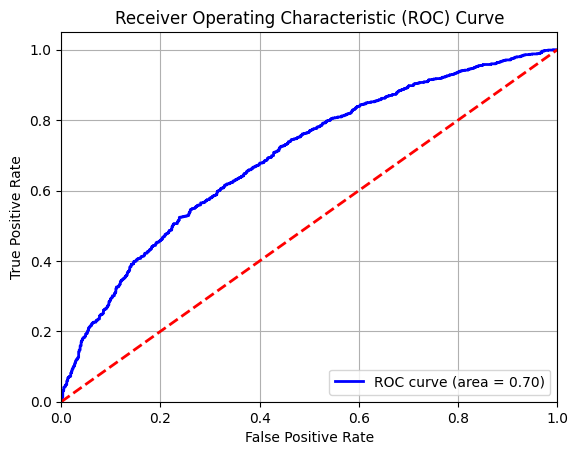

In [39]:
# Define loss function for single scatter hypothesis
def loss_function(xy, signal):
    """Negative log-likelihood of observing signal given mean response at xy. The log likelihood is defined as the sum of the log of the Poisson probabilities for each PMT, given the expected signal from the mean response at xy."""
    lce = mean_response(xy.reshape(1, 2)).squeeze()
    expected_signal = 10_000 * lce  # Assuming 10k photons emitted
    # Poisson likelihood
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

# Define single scatter optimizer
from scipy.optimize import minimize
# Single scatter optimizer
def single_scatter_optimizer(signal):
    """Optimizes parameters for single scatter hypothesis,
    taking the highest valued pmt as initial guess and
    then running a local optimizer"""

    pmt_high=np.argmax(signal)
    initial_guess = pmt_positions[pmt_high]
    result = minimize(lambda xy: loss_function(xy, signal), initial_guess, bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius)])
    return result.x

# Calculate chi squared statistic
def chi2(observed, expected):
    """Calculate the chi-squared statistic for observed vs expected signals"""
    # Avoid division by zero by using np.where, which replaces any zeroes with a small number
    expected = np.where(expected == 0, 1e-6, expected) 
    return np.sum((observed - expected) ** 2 / expected)

# Calculate chi squared statistic for many iterations of single and double scatters
def calculate_chi2_statistics_2(num_iterations=1000, photons=10_000, distance=10, ratio=0.5):
    """Calculate chi-squared statistics for many iterations of single and double scatters"""
    chi2_single = []
    chi2_double = []
    for _ in range(num_iterations):
        # Simulate single scatter
        signal_single = simulate_uniform_signals(1, photons).squeeze()
        # Optimize single scatter hypothesis
        xy_single = single_scatter_optimizer(signal_single)
        expected_single = 10_000 * mean_response(xy_single.reshape(1, 2)).squeeze()
        chi2_single.append(chi2(signal_single, expected_single))
        
        # Simulate double scatter
        signal_double = simulate_double_signal_constrained_parameters(1, photons, distance, ratio).squeeze()
        # Optimize single scatter hypothesis for double scatter signal
        xy_double = single_scatter_optimizer(signal_double)
        expected_double = 10_000 * mean_response(xy_double.reshape(1, 2)).squeeze()
        chi2_double.append(chi2(signal_double, expected_double))

    return np.array(chi2_single), np.array(chi2_double)

def calculate_chi2_statistics(num_iterations=1000, photons=10_000, distance=10, ratio=0.5):
    # Single scatter — fully vectorized
    signals_single = simulate_uniform_signals(num_iterations, photons)  # (N, pmts)
    xy_single = np.array([single_scatter_optimizer(s) for s in signals_single])
    expected_single = photons * mean_response(xy_single)  # (N, pmts) — one batch call
    chi2_single = np.sum((signals_single - expected_single)**2 / np.where(expected_single == 0, 1e-6, expected_single), axis=1)

    # Double scatter — vectorized after simulation
    signals_double = simulate_double_signal_constrained_parameters(num_iterations, photons, distance, ratio)
    xy_double = np.array([single_scatter_optimizer(s) for s in signals_double])
    expected_double = photons * mean_response(xy_double)
    chi2_double = np.sum((signals_double - expected_double)**2 / np.where(expected_double == 0, 1e-6, expected_double), axis=1)

    return chi2_single, chi2_double

def selection_operation(chi2_single, chi2_double, threshold):
    """Run selection on both arrays based on chi2 value, accepting values below the threshold
    and rejecting values at or above the threshold. Returns true positive rate and false positive rate.
    In the ideal case, all single scatters should be accepted and all double scatters should be rejected."""
    single_accepted = chi2_single < threshold
    double_accepted = chi2_double < threshold
    true_positive = np.sum(single_accepted) / len(chi2_single) #by formula TPR = TP / (TP + FN)
    false_positive = np.sum(double_accepted) / len(chi2_double) #by formula FPR = FP / (FP + TN)
    return true_positive, false_positive

def roc_curve(chi2_single, chi2_double):
    """Determine ROC curve, using as thresholds all unique chi2 values from both arrays..
    Returns false positive rates, true positive rates, and thresholds."""

    thresholds = np.sort(np.unique(np.concatenate((chi2_single, chi2_double))))
    tprs = []
    fprs = []
    for threshold in thresholds:
        tpr, fpr = selection_operation(chi2_single, chi2_double, threshold)
        tprs.append(tpr)
        fprs.append(fpr)
    return np.array(fprs), np.array(tprs), thresholds

def plot_roc_curve(chi2_single, chi2_double):
    """Plot ROC curve for some chi2 datapoints"""
    fprs, tprs, thresholds = roc_curve(chi2_single, chi2_double)
    roc_auc = auc(fprs, tprs)
    
    plt.figure()
    plt.plot(fprs, tprs, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

plot_roc_curve(*calculate_chi2_statistics(num_iterations=1000, photons=10_000, distance=5, ratio=0.5))

    






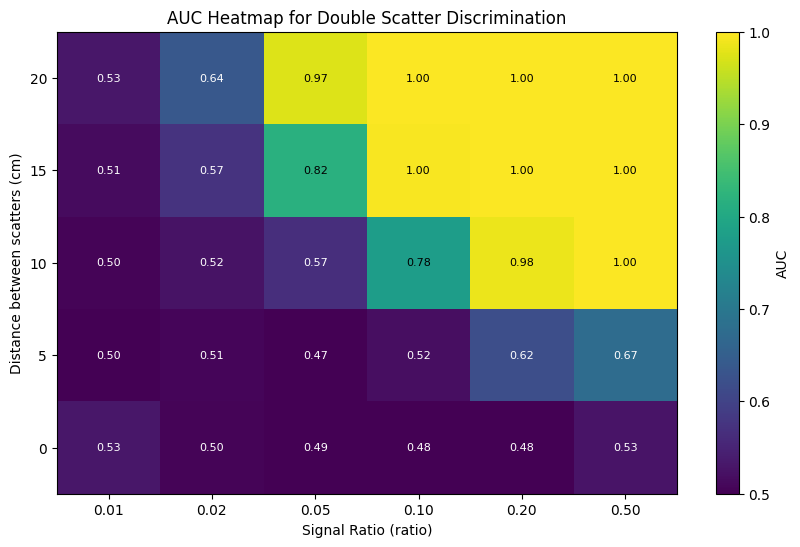

In [48]:
#AUC calculation and heatmap plotting for a range of distances and ratios

def AUC(chi2_single, chi2_double):
    """Calculate the area under the ROC curve for given chi2 values"""
    fprs, tprs, thresholds = roc_curve(chi2_single, chi2_double)
    return auc(fprs, tprs)

def AUC_heatmap(distances, ratios, num_iterations=1000, photons=10_000):
    """Calculate AUC for a range of distances and ratios, and plot as heatmap"""
    auc_values = np.zeros((len(distances), len(ratios)))
    for i, distance in enumerate(distances):
        for j, ratio in enumerate(ratios):
            chi2_single, chi2_double = calculate_chi2_statistics(num_iterations, photons, distance, ratio)
            auc_values[i, j] = AUC(chi2_single, chi2_double)
    
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(auc_values, cmap='viridis', vmin=0.5, vmax=1.0)
    plt.colorbar(label='AUC')
    for i in range(len(distances)):
        for j in range(len(ratios)):
            plt.text(j + 0.5, i + 0.5, f'{auc_values[i, j]:.2f}',
                ha='center', va='center',
                color='white' if auc_values[i, j] < 0.75 else 'black',
                fontsize=8)
    plt.xticks(np.arange(len(ratios)) + 0.5, [f'{r:.2f}' for r in ratios])
    plt.yticks(np.arange(len(distances)) + 0.5, [f'{d:.0f}' for d in distances])
    plt.xlabel('Signal Ratio (ratio)')
    plt.ylabel('Distance between scatters (cm)')
    plt.title('AUC Heatmap for Double Scatter Discrimination')
    plt.show()

distances = np.linspace(0, 20, 5)  # Example distances from 0 to 20 cm
ratios = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5])  # Example ratios from 0.1 to 0.9
AUC_heatmap(distances, ratios, num_iterations=500, photons=10_000)